# Getting the dataset and looking for the most corrolated features

In [198]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pmdarima as pm
from math import e, log

from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [110]:
df = pd.read_csv("mexico_weather.csv")
df = df.loc[:9000,:]

In [111]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

In [112]:
df["Temperature(F)"] = pd.to_numeric(df["Temperature(F)"])

In [113]:
df.head()

,DateTime,Station,Code,Country,State,City,Lat_num,Long_num,Elevation,Temperature(F),Dew Point(F),Humidity(%),Wind Speed(mph),Wind Gust(mph),Pressure(in),Wind,Condition
0,2017-01-01 00:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,54.0,46.0,77.0,2.0,0.0,24.92,SSE,Fair
1,2017-01-01 01:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,54.0,48.0,82.0,0.0,0.0,24.92,CALM,Fair
2,2017-01-01 02:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,52.0,46.0,82.0,3.0,0.0,24.89,S,Fair
3,2017-01-01 03:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,50.0,46.0,87.0,0.0,0.0,24.89,CALM,Fair
4,2017-01-01 04:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,48.0,45.0,87.0,2.0,0.0,24.89,ESE,Fair


In [114]:
display(df.describe())

,DateTime,Lat_num,Long_num,Elevation,Temperature(F),Dew Point(F),Humidity(%),Wind Speed(mph),Wind Gust(mph),Pressure(in)
count,9001,9.001000e+03,9.001000e+03,9001.0,9001.000000,9001.000000,9001.000000,9001.000000,9001.000000,9001.000000
mean,2017-07-07 12:00:00,2.051670e+01,-1.033167e+02,1528.0,67.406464,44.747084,52.059595,3.856664,0.470244,24.890892
min,2017-01-01 00:00:00,2.051670e+01,-1.033167e+02,1528.0,34.000000,-13.000000,2.000000,0.000000,0.000000,24.680000
25%,2017-04-04 18:00:00,2.051670e+01,-1.033167e+02,1528.0,61.000000,36.000000,30.000000,0.000000,0.000000,24.850000
50%,2017-07-07 12:00:00,2.051670e+01,-1.033167e+02,1528.0,68.000000,45.000000,53.000000,3.000000,0.000000,24.890000
75%,2017-10-09 06:00:00,2.051670e+01,-1.033167e+02,1528.0,75.000000,57.000000,73.000000,6.000000,0.000000,24.930000
max,2018-01-11 00:00:00,2.051670e+01,-1.033167e+02,1528.0,97.000000,77.000000,100.000000,35.000000,52.000000,25.175000
std,NaN,7.105822e-15,2.842329e-14,0.0,11.523244,13.136794,25.489400,4.314125,3.301969,0.066782


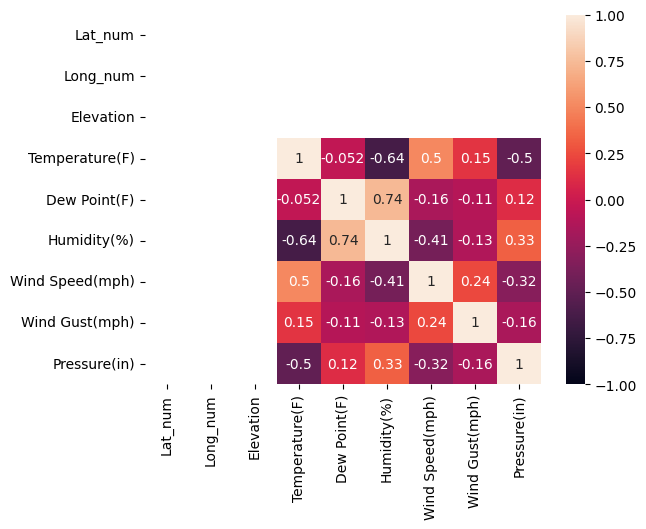

In [115]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.Figure(figsize=(12,12))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1)
plt.show()

# Start Of the method

In [116]:
df_bayesian = df[["DateTime","Temperature(F)","Humidity(%)"]]
display(df_bayesian)

,DateTime,Temperature(F),Humidity(%)
0,2017-01-01 00:00:00,54.0,77.0
1,2017-01-01 01:00:00,54.0,82.0
2,2017-01-01 02:00:00,52.0,82.0
3,2017-01-01 03:00:00,50.0,87.0
4,2017-01-01 04:00:00,48.0,87.0
...,...,...,...
8996,2018-01-10 20:00:00,63.0,45.0
8997,2018-01-10 21:00:00,59.0,55.0
8998,2018-01-10 22:00:00,57.0,63.0
8999,2018-01-10 23:00:00,55.0,67.0


In [199]:
df_bayesian

,DateTime,Temperature(F),Humidity(%),Went_up,Past_humidities_0,Past_humidities_1,Past_humidities_2,Past_humidities_3,Past_humidities_4,Past_humidities_5,...,Past_humidities_10,Past_humidities_11,Past_humidities_12,Past_humidities_13,Past_humidities_14,Past_humidities_15,Past_humidities_16,Past_humidities_17,Past_humidities_18,Past_humidities_19
20,2017-01-01 20:00:00,61.0,52.0,0.0,77.000000,82.000000,82.000000,87.000000,87.0,93.0,...,56.0,38.0,31.5,25.0,24.0,22.0,25.0,29.0,37.0,44.5
21,2017-01-01 21:00:00,59.0,59.0,0.0,82.000000,82.000000,87.000000,87.000000,93.0,87.0,...,38.0,31.5,25.0,24.0,22.0,25.0,29.0,37.0,44.5,59.0
22,2017-01-01 22:00:00,59.0,63.0,0.0,82.000000,87.000000,87.000000,93.000000,87.0,87.0,...,31.5,25.0,24.0,22.0,25.0,29.0,37.0,44.5,59.0,63.0
23,2017-01-01 23:00:00,54.0,72.0,0.0,87.000000,87.000000,93.000000,87.000000,87.0,76.0,...,25.0,24.0,22.0,25.0,29.0,37.0,44.5,59.0,63.0,72.0
24,2017-01-02 00:00:00,52.0,76.0,0.0,87.000000,93.000000,87.000000,87.000000,76.0,63.0,...,24.0,22.0,25.0,29.0,37.0,44.5,59.0,63.0,72.0,76.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8996,2018-01-10 20:00:00,63.0,45.0,0.0,64.000000,66.000000,69.333333,72.666667,76.0,81.0,...,36.0,31.0,26.0,23.0,26.0,28.0,27.0,37.0,40.0,45.0
8997,2018-01-10 21:00:00,59.0,55.0,0.0,66.000000,69.333333,72.666667,76.000000,81.0,87.0,...,31.0,26.0,23.0,26.0,28.0,27.0,37.0,40.0,45.0,55.0
8998,2018-01-10 22:00:00,57.0,63.0,0.0,69.333333,72.666667,76.000000,81.000000,87.0,74.0,...,26.0,23.0,26.0,28.0,27.0,37.0,40.0,45.0,55.0,63.0
8999,2018-01-10 23:00:00,55.0,67.0,0.0,72.666667,76.000000,81.000000,87.000000,74.0,51.5,...,23.0,26.0,28.0,27.0,37.0,40.0,45.0,55.0,63.0,67.0


In [117]:
list_past_humidities = []
for _ in range(20):
    list_past_humidities.append(None)
list_past_humidities.append([df_bayesian.iloc[i,2] for i in range(20)])

past_humidities = [df_bayesian.iloc[i,2] for i in range(20)]
for i in range(21,len(df_bayesian)):
    past_humidities.pop(0)
    past_humidities.append(df_bayesian.iloc[i,2])
    list_past_humidities.append(past_humidities.copy())

In [118]:
df_bayesian["Past_humidities"] = pd.Series(list_past_humidities)

/tmp/ipykernel_39306/2042229340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bayesian["Past_humidities"] = pd.Series(list_past_humidities)


In [119]:
def check_growth(x):
    index = x.name
    if index < 20:
        return None
    elif (df_bayesian["Temperature(F)"].iloc[index] - df_bayesian["Temperature(F)"].iloc[index-1])>0:
        return 1
    else:
        return 0 


df_bayesian["Went_up"] = df.apply(check_growth,axis=1)

/tmp/ipykernel_39306/1810904094.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bayesian["Went_up"] = df.apply(check_growth,axis=1)


In [120]:
df_bayesian.dropna(inplace=True)

/tmp/ipykernel_39306/2448035290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bayesian.dropna(inplace=True)


In [121]:
for i in range(20):
    df_bayesian[f"Past_humidities_{i}"] = df_bayesian.apply(lambda x: x.loc["Past_humidities"][i], axis = 1)

/tmp/ipykernel_39306/3397107198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bayesian[f"Past_humidities_{i}"] = df_bayesian.apply(lambda x: x.loc["Past_humidities"][i], axis = 1)
/tmp/ipykernel_39306/3397107198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bayesian[f"Past_humidities_{i}"] = df_bayesian.apply(lambda x: x.loc["Past_humidities"][i], axis = 1)
/tmp/ipykernel_39306/3397107198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

In [122]:
df_bayesian.drop(columns=["Past_humidities"],inplace=True)
train_features_bayesian = [x for x in list(df_bayesian.columns) if x.startswith("Past_humidities_")]

/tmp/ipykernel_39306/3577268090.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bayesian.drop(columns=["Past_humidities"],inplace=True)


In [123]:
train = df_bayesian["Temperature(F)"][:-int(0.2*len(df_bayesian))]
test = df_bayesian["Temperature(F)"][-int(0.2*len(df_bayesian)):]
train_df = df_bayesian[:-int(0.2*len(df_bayesian))]
test_df = df_bayesian[-int(0.2*len(df_bayesian)):]
time_stamps = int(0.2*len(df_bayesian))+1

train_df_bayesian = df_bayesian[:-int(0.2*len(df_bayesian))]
test_df_bayesian = df_bayesian[-int(0.2*len(df_bayesian)):]
time_stamps = int(0.2*len(df_bayesian))+1

In [124]:
X_train = train_df_bayesian[train_features_bayesian]
y_train = train_df_bayesian["Went_up"]

X_test = test_df_bayesian[train_features_bayesian]
y_test = test_df_bayesian["Went_up"]

In [132]:
model = CategoricalNB()
model.fit(X_train,y_train)
y_pred_bayesian = model.predict(X_test)
y_proba = model.predict_proba(X_test)
confidence = y_proba.max(axis=1)
confidence_percent = confidence * 100

In [126]:
dictionnaire = {}
for x in confidence_percent:
    x = int(x)
    if x in dictionnaire:
        dictionnaire[x] += 1
    else:
        dictionnaire[x] = 1 
print(dictionnaire)

{98: 74, 99: 1345, 97: 37, 59: 3, 94: 21, 95: 25, 90: 10, 55: 5, 81: 7, 57: 4, 93: 20, 87: 9, 64: 4, 96: 25, 69: 7, 84: 14, 63: 8, 85: 7, 70: 4, 88: 6, 77: 6, 78: 6, 89: 10, 72: 3, 82: 6, 51: 3, 61: 6, 58: 7, 91: 7, 53: 2, 50: 7, 67: 4, 62: 5, 60: 4, 74: 6, 71: 2, 66: 5, 92: 10, 73: 2, 68: 2, 65: 7, 76: 9, 80: 10, 79: 4, 54: 5, 75: 3, 52: 6, 86: 6, 83: 6, 56: 2}


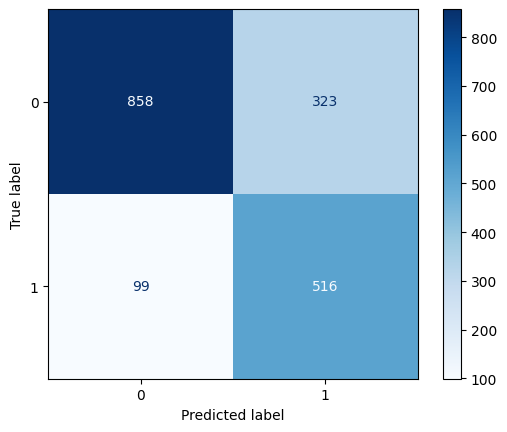

In [127]:
cm = confusion_matrix(y_test,y_pred_bayesian)
disp = ConfusionMatrixDisplay(confusion_matrix= cm)
disp.plot(cmap="Blues")
plt.show()

# Using that to improve a model the ARIMA mdoel

In [128]:
model_arima = ARIMA(train,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py

* INCORPORATING THE PROBABILITIES IN y_pred

In [141]:
probability_of_growth = []
for i in range(len(y_pred_bayesian)):
    if y_pred_bayesian[i] == 1:
        probability_of_growth.append(confidence[i])
    else:
        probability_of_growth.append(1-confidence[i])

In [145]:
y_pred_values = list(y_pred)

In [189]:
y_pred_updated = []
for i in range(len(y_pred_values)):
    proba_growth = probability_of_growth[i]
    if proba_growth < 0.5:
        y_pred_updated.append(y_pred_values[i] * log(e -0.5 + proba_growth))
    else:
        y_pred_updated.append(y_pred_values[i])

* Displaying the results

In [195]:
prediction = pd.DataFrame({"Temperature(F)":y_pred_updated})
prediction.index = range(7205,7205+len(prediction))
prediction["DateTime"] = test_df["DateTime"]

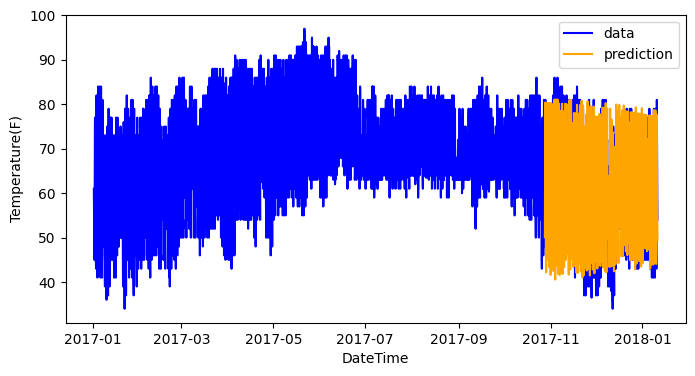

In [196]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_bayesian,x="DateTime",y="Temperature(F)",color="blue",label="data")
sns.lineplot(data=prediction,x="DateTime",y="Temperature(F)",color="orange",label="prediction")
plt.show()

In [197]:
mae = mean_absolute_error(test, y_pred_updated)
rmse = mean_squared_error(test, y_pred_updated, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred_updated)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 6.480912697530564
RMSE: 8.341799478588483
MAPE: 0.11132162129111212
